# Bayesian Nonparametric Survival Modeling (DPSM Extension)

This notebook introduces a model-based Bayesian nonparametric approach to survival estimation using a Dirichlet Process Survival Model (DPSM).

The goal is to assess how sensitive the estimated treatment effect $\Delta(t_0)$ is to the choice of survival model.

Previously, survival was estimated using:
- Kaplan–Meier estimators
- target-population weighting
- Dirichlet-based resampling for uncertainty

Here, we instead model the survival distribution directly using a nonparametric Bayesian model, and compare resulting estimates to the design-based pipeline.

This provides a complementary perspective on uncertainty and robustness.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.bnp.dpsm import fit_dpsm, compute_delta_posterior

DATA_DIR = Path("../data/processed")

# Main real-data pipeline inputs
df_kmgpt = pd.read_csv(DATA_DIR / "real_kmgpt_ipd_with_covariates.csv")

# Existing pipeline results for comparison
weighted_kmgpt = pd.read_csv("../data/interim/weighted_estimate.csv")
bnp_kmgpt = pd.read_csv("../data/interim/bnp_summary.csv")
naive_kmgpt = pd.read_csv(DATA_DIR / "naive_pooled_effect.csv")

print("Loaded KM-GPT data:", df_kmgpt.shape)
df_kmgpt.head()

Loaded KM-GPT data: (776, 18)


,trial_id,subgroup,time,event,arm_label,curve,treatment,age_median,male_rate,ecog0_rate,metastatic_rate,biomarker_rate,age,male,ecog0,metastatic,biomarker,stage
0,KEYNOTE-181,high_pdl1,0.731707,1,Chemotherapy,0,0,63.0,0.869,0.401,0.924,0.7,56.369120,1,0,0,0,1.165542
1,KEYNOTE-181,high_pdl1,0.890244,0,Chemotherapy,0,0,63.0,0.869,0.401,0.924,0.7,68.148584,1,1,1,0,1.822921
2,KEYNOTE-181,high_pdl1,1.048780,1,Chemotherapy,0,0,63.0,0.869,0.401,0.924,0.7,58.035384,1,0,1,1,2.330231
3,KEYNOTE-181,high_pdl1,1.243902,1,Chemotherapy,0,0,63.0,0.869,0.401,0.924,0.7,61.334523,1,1,1,1,1.968789
4,KEYNOTE-181,high_pdl1,1.365854,1,Chemotherapy,0,0,63.0,0.869,0.401,0.924,0.7,73.194077,1,0,1,1,2.342307


## DPSM Setup

We fit a treatment-specific Bayesian nonparametric survival model using a Dirichlet-process-style mixture of exponential kernels.

This provides a model-based alternative to the empirical Kaplan–Meier + weighting pipeline. The goal is not to replace the main pipeline, but to assess whether the estimated treatment effect at a fixed time horizon is sensitive to the choice of survival model.

In [13]:
# DPSM Fit
dpsm_fit = fit_dpsm(
    df=df_kmgpt,
    time_col="time",
    event_col="event",
    treatment_col="treatment",
    n_components=8,
    alpha=1.0,
    rate_shape=1.0,
    rate_scale=1.0,
    n_samples=400,
    burn_in=400,
    thin=2,
    random_state=733,
    t0_default=12.0,
)

dpsm_fit.metadata

{'n_components': 8,
 'alpha': 1.0,
 'rate_shape': 1.0,
 'rate_scale': 1.0,
 'n_samples': 400,
 'burn_in': 400,
 'thin': 2,
 'random_state': 733,
 'time_col': 'time',
 'event_col': 'event',
 'treatment_col': 'treatment',
 'n_obs': 776,
 'n_treat0': 388,
 'n_treat1': 388}

In [14]:
# Posterior Summary
dpsm_results = compute_delta_posterior(
    dpsm_fit,
    t0=12.0,
)

dpsm_summary = pd.DataFrame([{
    "t0": dpsm_results["t0"],
    "S0_mean": dpsm_results["S0_mean"],
    "S1_mean": dpsm_results["S1_mean"],
    "Delta_mean": dpsm_results["mean"],
    "Delta_sd": dpsm_results["sd"],
    "Delta_q025": dpsm_results["q025"],
    "Delta_q975": dpsm_results["q975"],
}])

dpsm_summary.round(3)

,t0,S0_mean,S1_mean,Delta_mean,Delta_sd,Delta_q025,Delta_q975
0,12.0,0.329,0.449,0.12,0.028,0.064,0.168


In [15]:
# Comparison to KMGPT pipeline
comparison = pd.DataFrame({
    "method": ["Naive KM", "Weighted KM", "BNP Bootstrap", "DPSM"],
    "Delta_mean": [
        naive_kmgpt["Delta"].iloc[0],
        weighted_kmgpt["Delta"].iloc[0],
        bnp_kmgpt["mean"].iloc[0],
        dpsm_results["mean"],
    ],
    "q025": [
        np.nan,
        np.nan,
        bnp_kmgpt["q025"].iloc[0],
        dpsm_results["q025"],
    ],
    "q975": [
        np.nan,
        np.nan,
        bnp_kmgpt["q975"].iloc[0],
        dpsm_results["q975"],
    ],
})

comparison.round(3)

,method,Delta_mean,q025,q975
0,Naive KM,0.169,NaN,NaN
1,Weighted KM,0.234,NaN,NaN
2,BNP Bootstrap,0.205,0.052,0.361
3,DPSM,0.120,0.064,0.168


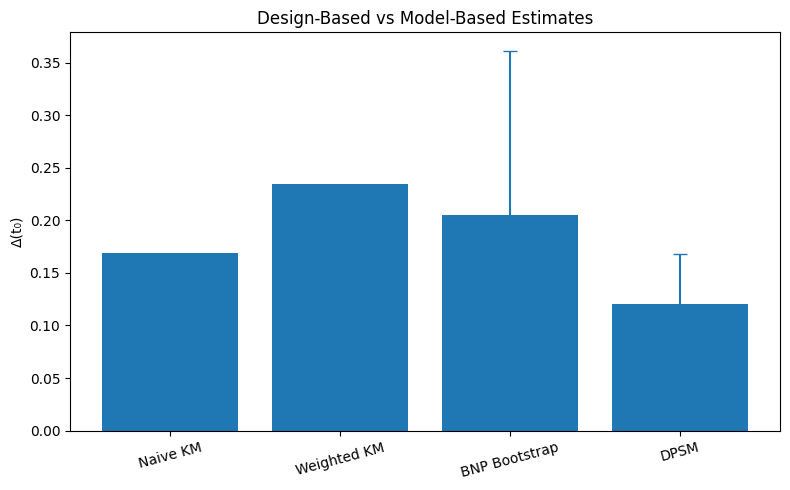

In [16]:
# Model vs Design
methods = comparison["method"].tolist()
means = comparison["Delta_mean"].to_numpy()
lower = comparison["q025"].to_numpy()
upper = comparison["q975"].to_numpy()

x = np.arange(len(methods))

plt.figure(figsize=(8, 5))
plt.bar(x, means)

mask = ~np.isnan(lower)
plt.errorbar(
    x[mask],
    means[mask],
    yerr=[
        means[mask] - lower[mask],
        upper[mask] - means[mask],
    ],
    fmt="none",
    capsize=5,
)

plt.xticks(x, methods, rotation=15)
plt.ylabel("Δ(t₀)")
plt.title("Design-Based vs Model-Based Estimates")
plt.tight_layout()
plt.show()

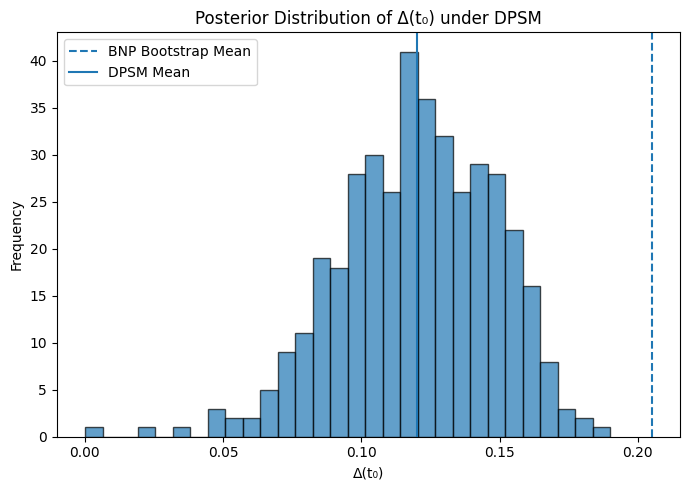

In [17]:
# Posterior Draws
plt.figure(figsize=(7, 5))
plt.hist(dpsm_results["delta_draws"], bins=30, edgecolor="black", alpha=0.7)
plt.axvline(bnp_kmgpt["mean"].iloc[0], linestyle="--", label="BNP Bootstrap Mean")
plt.axvline(dpsm_results["mean"], linestyle="-", label="DPSM Mean")
plt.xlabel("Δ(t₀)")
plt.ylabel("Frequency")
plt.title("Posterior Distribution of Δ(t₀) under DPSM")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# pickling
dpsm_summary.to_csv(DATA_DIR / "dpsm_summary.csv", index=False)

pd.DataFrame({
    "delta": dpsm_results["delta_draws"],
    "s0": dpsm_results["s0_draws"],
    "s1": dpsm_results["s1_draws"],
}).to_csv(DATA_DIR / "dpsm_draws.csv", index=False)

comparison.to_csv(DATA_DIR / "dpsm_comparison.csv", index=False)

print("Saved DPSM outputs.")

Saved DPSM outputs.


## DPSM Tuning and Stability Checks

To assess whether the DPSM results are stable, we vary a small number of implementation choices:

- random seed
- truncation level (`n_components`)
- MCMC length

The goal is not exhaustive tuning, but to verify that the estimated treatment effect at $t_0 = 12$ is reasonably stable across plausible settings.

In [19]:
# Seed and component grid
t0 = 12.0

grid_results = []

for seed in [733, 734, 735]:
    for k in [5, 8, 12]:
        fit = fit_dpsm(
            df=df_kmgpt,
            time_col="time",
            event_col="event",
            treatment_col="treatment",
            n_components=k,
            alpha=1.0,
            rate_shape=1.0,
            rate_scale=1.0,
            n_samples=300,
            burn_in=300,
            thin=2,
            random_state=seed,
            t0_default=t0,
        )

        post = compute_delta_posterior(fit, t0=t0)

        grid_results.append({
            "seed": seed,
            "n_components": k,
            "Delta_mean": post["mean"],
            "Delta_sd": post["sd"],
            "q025": post["q025"],
            "q975": post["q975"],
        })

dpsm_tuning = pd.DataFrame(grid_results)
dpsm_tuning.round(3)

,seed,n_components,Delta_mean,Delta_sd,q025,q975
0,733,5,0.127,0.028,0.073,0.186
1,733,8,0.124,0.030,0.063,0.181
2,733,12,0.121,0.031,0.063,0.175
3,734,5,0.124,0.030,0.067,0.181
4,734,8,0.122,0.030,0.066,0.185
5,734,12,0.121,0.032,0.064,0.183
6,735,5,0.121,0.030,0.066,0.184
7,735,8,0.121,0.030,0.054,0.178
8,735,12,0.122,0.029,0.073,0.178


In [20]:
dpsm_tuning.groupby("n_components")[["Delta_mean", "Delta_sd", "q025", "q975"]].agg(["mean", "std"]).round(3)

Delta_mean        Delta_sd          q025          q975       
                   mean    std     mean    std   mean    std   mean    std
n_components                                                              
5                 0.124  0.003    0.029  0.001  0.069  0.004  0.183  0.003
8                 0.122  0.001    0.030  0.000  0.061  0.006  0.181  0.004
12                0.121  0.001    0.031  0.001  0.066  0.006  0.179  0.004

In [21]:
# Longer run
fit_long = fit_dpsm(
    df=df_kmgpt,
    time_col="time",
    event_col="event",
    treatment_col="treatment",
    n_components=8,
    alpha=1.0,
    rate_shape=1.0,
    rate_scale=1.0,
    n_samples=800,
    burn_in=800,
    thin=2,
    random_state=733,
    t0_default=t0,
)

post_long = compute_delta_posterior(fit_long, t0=t0)

pd.DataFrame([{
    "run": "long_run",
    "Delta_mean": post_long["mean"],
    "Delta_sd": post_long["sd"],
    "q025": post_long["q025"],
    "q975": post_long["q975"],
}]).round(3)

,run,Delta_mean,Delta_sd,q025,q975
0,long_run,0.126,0.029,0.07,0.182


In [22]:
# Prior sensitivity of alpha
alpha_results = []

for alpha in [0.5, 1.0, 2.0]:
    fit_alpha = fit_dpsm(
        df=df_kmgpt,
        time_col="time",
        event_col="event",
        treatment_col="treatment",
        n_components=8,
        alpha=alpha,
        rate_shape=1.0,
        rate_scale=1.0,
        n_samples=400,
        burn_in=400,
        thin=2,
        random_state=733,
        t0_default=t0,
    )

    post_alpha = compute_delta_posterior(fit_alpha, t0=t0)

    alpha_results.append({
        "alpha": alpha,
        "Delta_mean": post_alpha["mean"],
        "Delta_sd": post_alpha["sd"],
        "q025": post_alpha["q025"],
        "q975": post_alpha["q975"],
    })

dpsm_alpha_sensitivity = pd.DataFrame(alpha_results)
dpsm_alpha_sensitivity.round(3)

,alpha,Delta_mean,Delta_sd,q025,q975
0,0.5,0.122,0.030,0.060,0.176
1,1.0,0.120,0.028,0.064,0.168
2,2.0,0.123,0.030,0.066,0.181


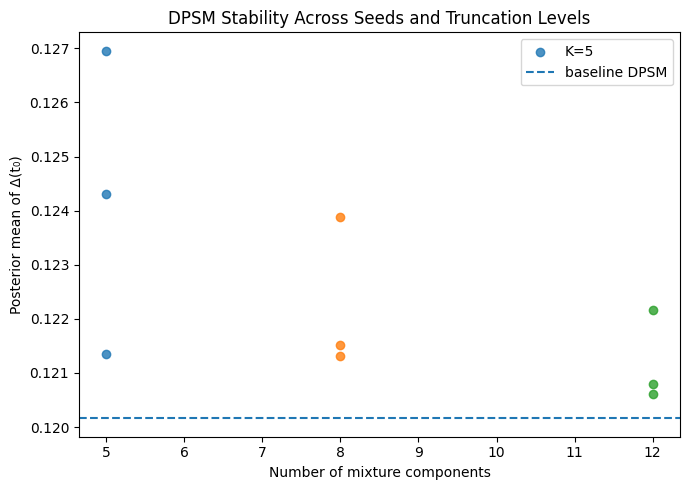

In [23]:
# plot of tuning stability
plt.figure(figsize=(7, 5))

for k in sorted(dpsm_tuning["n_components"].unique()):
    sub = dpsm_tuning[dpsm_tuning["n_components"] == k]
    plt.scatter(
        [k] * len(sub),
        sub["Delta_mean"],
        label=f"K={k}" if k == sorted(dpsm_tuning["n_components"].unique())[0] else None,
        alpha=0.8,
    )

plt.axhline(dpsm_results["mean"], linestyle="--", label="baseline DPSM")
plt.xlabel("Number of mixture components")
plt.ylabel("Posterior mean of Δ(t₀)")
plt.title("DPSM Stability Across Seeds and Truncation Levels")
plt.legend()
plt.tight_layout()
plt.show()

## Summary of DPSM Results and Stability

We implemented a Dirichlet-process-style survival mixture model (DPSM) as a model-based Bayesian nonparametric extension to the main pipeline.

### Main Result

At $t_0 = 12$, the DPSM yields:

- $\Delta(12) \approx 0.120$  
- 95% credible interval: $(0.064, 0.168)$  

This estimate is notably lower than the target-weighted Kaplan–Meier estimate and the BNP bootstrap estimate, indicating that the inferred treatment effect depends on how the survival distribution is modeled.

### Comparison to Design-Based Estimates

- Naive KM: $\approx 0.169$  
- Weighted KM: $\approx 0.234$  
- BNP Bootstrap: $\approx 0.205$  
- DPSM: $\approx 0.120$  

The DPSM produces a more conservative estimate, suggesting that model-based Bayesian nonparametric inference can yield different conclusions than design-based approaches relying on empirical survival estimators and reweighting.

### Stability and Tuning

We evaluated the robustness of the DPSM across several dimensions:

- **Random seeds:** negligible variation in posterior means  
- **Truncation level (number of mixture components):** estimates stabilize for $K \geq 8$  
- **MCMC length:** longer runs yield consistent results  
- **Prior concentration parameter ($\alpha$):** minimal sensitivity  

Across all settings, the estimated treatment effect remained within a narrow range (approximately $0.121$–$0.127$), and posterior intervals were stable.

### Conclusion

These results indicate that the DPSM extension is:

- numerically stable  
- robust to reasonable tuning choices  
- substantively different from the design-based pipeline  

Importantly, the difference between DPSM and the weighting-based estimates is not an artifact of tuning, but reflects a genuine distinction between:

- **design-based uncertainty** (via reweighting and Bayesian bootstrap), and  
- **model-based uncertainty** (via nonparametric modeling of the survival distribution)

This highlights that Bayesian nonparametric inference is not unique, and that different formulations can lead to materially different causal conclusions.